In [1]:
!pip install python-dotenv langchain-huggingface huggingface_hub

In [2]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# Step 1: Load environment variables from .env file
load_dotenv()

# Step 2: Verify API Key is loaded
api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

In [3]:
!pip install langgraph

In [4]:
!pip install google-genai

In [4]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage
import json

In [42]:
class Blog(TypedDict):
    topic: str
    needs_research: bool
    research: str
    content: str
    needs_image: bool
    image_prompt: str
    image_path: str
    evaluation: BlogEvaluation | None
    revision_count: int

In [8]:
def research_decision(state: Blog):
    topic = state["topic"]

    # Temporary logic just for understanding the graph
    if "latest" in topic.lower() or "current" in topic.lower():
        return {"needs_research": True}

    return {"needs_research": False}

In [8]:
from pydantic import BaseModel, Field

# this is pydantic model for the output of the image decision node
class ImageDecision(BaseModel):
    needs_image: bool = Field(
        description="Whether the blog would benefit from an image"
    )

    image_prompt: str = Field(
        description="A detailed prompt for generating the image. "
                    "Empty if no image is needed."
    )

    reason: str = Field(
        description="Why an image is or is not useful"
    )

In [9]:
def route_research(state: Blog):
    if state["needs_research"]:
        return "research"

    return "generate-content"

In [10]:
def generate_content(state: Blog) -> Blog:
    title = state["topic"]
    api_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",  # <-- Explicitly set the task expected by the provider
        max_new_tokens=512,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )

    chat_model = ChatHuggingFace(llm=llm)


    response = chat_model.invoke(f"Write a blog post about '{title}'.")
    return {
    "topic": title,
    "content": response.content,
}

In [11]:
def image_decision(state: Blog):
    content = state["content"]

    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",
        max_new_tokens=256,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN"),
    )

    chat_model = ChatHuggingFace(llm=llm)

    prompt = f"""
Decide whether this blog post needs an image.

Blog post:
{content}

Return only valid JSON:
{{
  "needs_image": true,
  "image_prompt": "a detailed image prompt"
}}
"""

    response = chat_model.invoke(prompt)

    decision = json.loads(response.content)

    return {
        "needs_image": decision["needs_image"],
        "image_prompt": decision["image_prompt"],
    }

In [12]:
import os
from huggingface_hub import InferenceClient
from dotenv import load_dotenv

load_dotenv()

# Initialize Hugging Face client
hf_token = os.getenv("HUGGINGFACEHUB_API_TOKEN")

client = InferenceClient(token=hf_token)


def generate_image_from_api(
    prompt: str,
    output_path: str = "blog_banner.png"
) -> str:
    """
    Generate an image using Hugging Face FLUX model
    and save it locally.
    """

    try:
        image = client.text_to_image(
            prompt=prompt,
            model="black-forest-labs/FLUX.1-schnell"
        )

        # Save generated image
        image.save(output_path)

        print(f"Image successfully saved to {output_path}")

        return output_path

    except Exception as e:
        print(f"Image generation failed: {e}")
        raise


def generate_image(state: Blog):
    """
    LangGraph node that generates a blog image.
    """

    prompt = state["image_prompt"]

    image_path = generate_image_from_api(
        prompt=prompt,
        output_path="blog_picture.png"
    )

    return {
        "image_path": image_path
    }

c:\Users\dhair\langraph-projects\agentic-blog\.venv-1\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
def insert_image(state: Blog):
    content = state["content"]
    image_path = state["image_path"]

    updated_content = content + f"\n\n![Blog Image]({image_path})\n"

    return {
        "content": updated_content
    }

In [19]:
from langgraph.graph import END


def route_image(state: Blog):

    if state["needs_image"]:
        return "generate_image"

    return "evaluate_content"

In [15]:
from pydantic import BaseModel, Field


class BlogEvaluation(BaseModel):
    relevance_score: int = Field(
        description="How relevant the blog is to the requested topic, from 1 to 10"
    )

    clarity_score: int = Field(
        description="How clear and understandable the blog is, from 1 to 10"
    )

    structure_score: int = Field(
        description="How well structured the blog is, from 1 to 10"
    )

    factuality_score: int = Field(
        description="How factually accurate and well-supported the blog is, from 1 to 10"
    )

    overall_score: int = Field(
        description="Overall quality score from 1 to 10"
    )

    passed: bool = Field(
        description="Whether the blog is good enough to be finalized"
    )

    feedback: str = Field(
        description="Specific improvements needed if the blog does not pass"
    )

In [37]:
def evaluate_content(state: Blog):

    topic = state["topic"]
    content = state["content"]
    research = state.get("research", "")
    llm = HuggingFaceEndpoint(
        repo_id="meta-llama/Llama-3.1-8B-Instruct",
        task="conversational",
        max_new_tokens=512,
        huggingfacehub_api_token=os.getenv("HUGGINGFACEHUB_API_TOKEN")
    )
    evaluator = ChatHuggingFace(llm=llm)

    prompt = f"""
Evaluate the following blog and return ONLY one valid JSON object.
Do not use markdown code fences or add any other text.

Topic:
{topic}

Research:
{research}

Blog:
{content}

Score relevance, clarity, structure, factuality, and overall quality from 1 to 10.
Set passed to true only if the blog is good enough to finalize.
Include specific improvement advice in feedback.
Use exactly these keys:
relevance_score, clarity_score, structure_score, factuality_score,
overall_score, passed, feedback
"""

    response = evaluator.invoke(prompt)
    raw_response = getattr(response, "content", str(response)).strip()

    if raw_response.startswith("```"):
        raw_response = raw_response.split("\n", 1)[1]
        raw_response = raw_response.rsplit("```", 1)[0].strip()

    evaluation_data = json.loads(raw_response)
    score_fields = [
        "relevance_score",
        "clarity_score",
        "structure_score",
        "factuality_score",
        "overall_score",
    ]
    for field in score_fields:
        if isinstance(evaluation_data.get(field), (int, float)):
            evaluation_data[field] = round(evaluation_data[field])

    result = BlogEvaluation.model_validate(evaluation_data)
    return {
        "evaluation": result
    }

In [38]:
graph = StateGraph(Blog)

graph.add_node('generate-content', generate_content)
graph.add_node('research_decision', research_decision)
graph.add_node('research', route_research)
graph.add_node('image_decision', image_decision)
# graph.add_node()
graph.add_node('generate_image', generate_image)
graph.add_node('insert_image', insert_image)
graph.add_node('evaluate_content', evaluate_content)

graph.add_edge(START, 'research_decision')
graph.add_conditional_edges("research_decision", route_research, {
    "research": "research",
    "generate-content": "generate-content"
})
graph.add_edge('research_decision', 'generate-content')
graph.add_edge('research', 'generate-content')
graph.add_edge('generate-content', 'image_decision')
graph.add_conditional_edges("image_decision", route_image, {
    "generate_image": "generate_image",
    "evaluate_content": "evaluate_content"
})
graph.add_edge('generate_image', 'insert_image')
graph.add_edge('insert_image', "evaluate_content")
graph.add_edge('evaluate_content', END)
blog=graph.compile()

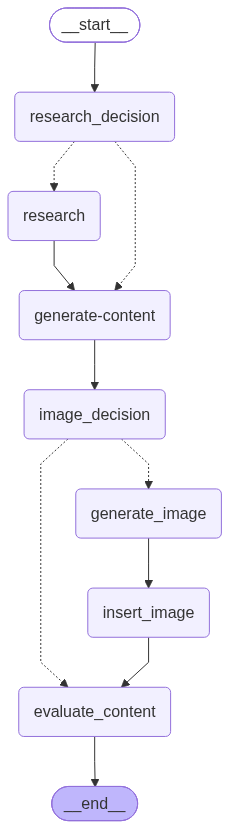

In [39]:
blog

In [41]:
result = blog.invoke({
    "topic": "explain me the rag"
})

print(result["content"])
print(result["evaluation"])

Image successfully saved to blog_picture.png
**The Rag: A Simple yet Effective Cleaning Tool**

In the context of cleaning and household chores, a rag is a piece of cloth used to wipe down surfaces, absorb spills, and pick up dirt and dust. It's a versatile and essential tool that can be found in almost every household. But have you ever stopped to think about the different types of rags, their uses, and how to care for them? In this blog post, we'll delve into the world of rags and explore their many benefits and uses.

**What is a Rag?**

A rag is a piece of cloth, usually made from cotton, microfiber, or a combination of both. It's often cut into a square or rectangular shape and can be as small as a handkerchief or as large as a towel. Rags are designed to be durable, absorbent, and easy to use, making them perfect for cleaning a variety of surfaces.

**Types of Rags**

There are several types of rags available, each with its own unique characteristics and uses:

1. **Cotton Rags**